[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd4-vicreg/02_extract_and_watch_skeletons.ipynb)

# 02. Extract and watch BlazePose skeletons

Use each annotation's frame span and bbox to extract the intended walker without compressing the gait timeline.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run it:** locally, use `uv sync` then `uv run jupyter lab` from this folder. In Colab, use the badge and run the setup cell. Restart the kernel after changing `experiments/sjepa/gavd4-vicreg/.env`.

**Keep the walk visible:** notebook 01 opens the source video, and notebook 02 shows frame, bbox, and skeleton alignment. Revisit those views whenever a latent or classifier result looks surprising.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd4-vicreg"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD3_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD3_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        str(PROJECT_ROOT / "data"),
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "data" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD3_CACHE_DIR", TUTORIAL_DIR / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD3_ARTIFACT_DIR", CACHE_DIR / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


SMOKE MODE: hand-authored motions test code paths only. They have no pathophysiological or clinical validity.
mode: smoke
project: /Users/theodoremui/dev/alexpose
GAVD CSVs: /Users/theodoremui/dev/alexpose/data/gavd
YouTube cache: /Users/theodoremui/dev/alexpose/data/youtube
artifacts: /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd4-vicreg/cache/artifacts/smoke


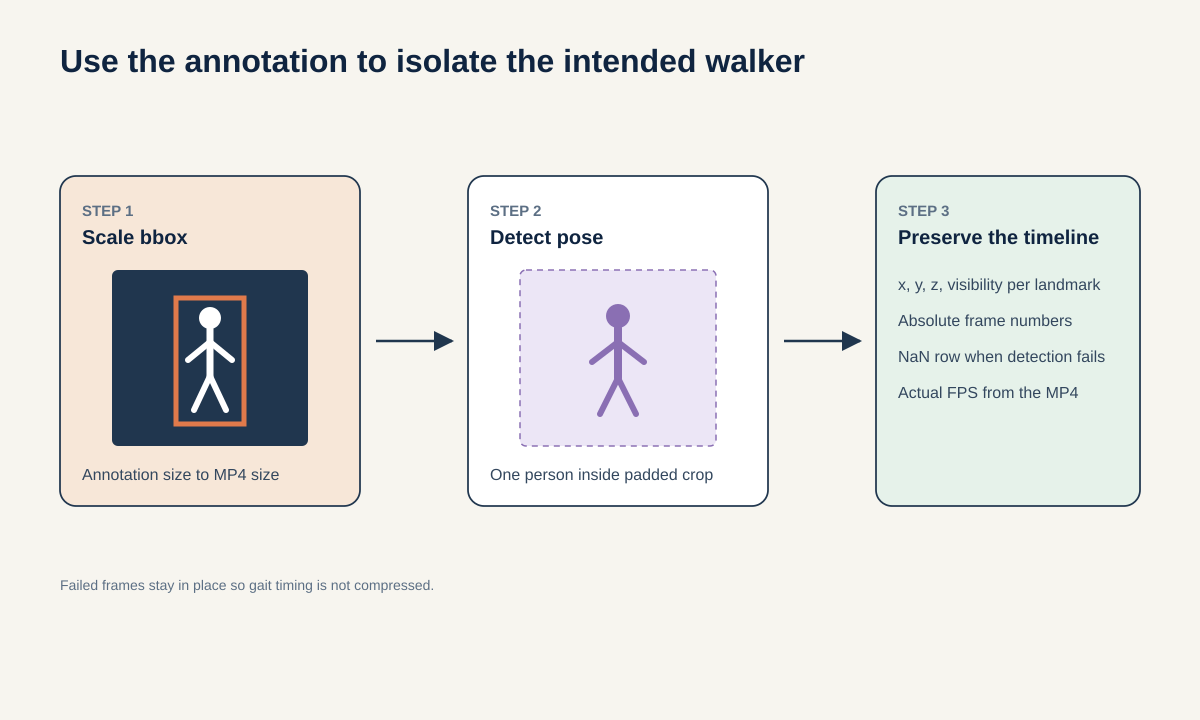

In [2]:
show_tutorial_svg("05_pose_extraction.svg")


In [3]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


In [4]:
import ast
from urllib.parse import parse_qs, urlparse

CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
CONDITION_ALIASES = {
    "normal": ["normal"],
    "parkinsons": ["parkinsons", "parkinson", "parkinsons disease"],
    "stroke": ["stroke"],
    "cerebralpalsy": ["cerebralpalsy", "cerebral palsy", "cerebral_palsy"],
    "myopathic": ["myopathic", "myopathy"],
}
COHORT_ROOT = PROJECT_ROOT / "data" / "gavd"
EXPECTED_SEQUENCE_COUNTS = {
    "normal": 12,
    "parkinsons": 9,
    "stroke": 12,
    "cerebralpalsy": 16,
    "myopathic": 47,
}


def canonical_condition(value):
    compact = str(value).strip().lower().replace("_", " ")
    for canonical, aliases in CONDITION_ALIASES.items():
        if compact in [a.replace("_", " ") for a in aliases]:
            return canonical
    return compact.replace(" ", "")


def resolve_condition_folder(root, condition):
    root = Path(root)
    for alias in CONDITION_ALIASES[condition]:
        candidate = root / alias
        if candidate.exists():
            return candidate
    return root / condition


def youtube_id_from_url(value):
    if value is None or pd.isna(value):
        return None
    text = str(value).strip()
    parsed = urlparse(text)
    if parsed.netloc.endswith("youtu.be"):
        value = parsed.path.strip("/").split("/")[0]
        return value if len(value) == 11 else None
    if "youtube.com" in parsed.netloc:
        value = parse_qs(parsed.query).get("v", [None])[0]
        return value if value and len(value) == 11 else None
    return text if len(text) == 11 else None


def safe_literal(value):
    if value is None or pd.isna(value):
        return {}
    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, dict) else {}
    except (ValueError, SyntaxError):
        return {}


def selected_csv_paths(root=DATA_GAVD_DIR, cohort_root=COHORT_ROOT):
    """Resolve the fixed 96-sequence tutorial cohort against a data source."""
    paths = {}
    for condition in CONDITIONS:
        source_folder = resolve_condition_folder(root, condition)
        cohort_folder = resolve_condition_folder(cohort_root, condition)
        selected_ids = sorted(path.stem for path in cohort_folder.glob("*.csv"))
        expected = EXPECTED_SEQUENCE_COUNTS[condition]
        if len(selected_ids) != expected:
            raise ValueError(
                f"Tutorial cohort definition for {condition} has "
                f"{len(selected_ids)} sequences; expected {expected}: {cohort_folder}"
            )
        missing = [
            sequence_id for sequence_id in selected_ids
            if not (source_folder / f"{sequence_id}.csv").is_file()
        ]
        if missing:
            raise FileNotFoundError(
                f"Data source {source_folder} is missing {len(missing)} selected "
                f"{condition} sequences; first missing IDs: {missing[:5]}"
            )
        paths[condition] = [
            source_folder / f"{sequence_id}.csv"
            for sequence_id in selected_ids
        ]
    return paths


def scan_gavd_manifest(root=DATA_GAVD_DIR, cohort_root=COHORT_ROOT):
    rows = []
    selected_paths = selected_csv_paths(root, cohort_root)
    for condition in CONDITIONS:
        for csv_path in selected_paths[condition]:
            frame_table = pd.read_csv(csv_path)
            required = {"seq", "frame_num", "bbox", "id", "url"}
            missing = required.difference(frame_table.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing {sorted(missing)}")
            if frame_table.empty:
                raise ValueError(f"Selected GAVD file is empty: {csv_path}")
            sequence_ids = frame_table["seq"].dropna().astype(str).unique()
            if len(sequence_ids) != 1:
                raise ValueError(f"{csv_path} contains {len(sequence_ids)} sequence ids")
            if sequence_ids[0] != csv_path.stem:
                raise ValueError(
                    f"Sequence ID {sequence_ids[0]} does not match filename {csv_path.stem}"
                )
            first = frame_table.iloc[0]
            video_id = youtube_id_from_url(first.get("id")) or youtube_id_from_url(first.get("url"))
            if video_id is None:
                raise ValueError(f"Could not parse a YouTube ID from {csv_path}")
            frames = pd.to_numeric(frame_table["frame_num"], errors="raise").astype(int)
            rows.append({
                "condition": condition,
                "dataset_annotation": first.get("dataset"),
                "gait_pattern_annotation": first.get("gait_pat"),
                "sequence_id": sequence_ids[0],
                "csv_path": str(csv_path),
                "video_id": video_id,
                "url": first.get("url"),
                "first_frame": int(frames.min()),
                "last_frame": int(frames.max()),
                "n_annotated_frames": int(frames.nunique()),
                "cam_view": first.get("cam_view"),
                "source_height": safe_literal(first.get("vid_info")).get("height"),
                "source_width": safe_literal(first.get("vid_info")).get("width"),
            })
    manifest = pd.DataFrame(rows)
    if manifest["sequence_id"].duplicated().any():
        raise ValueError("Sequence IDs must be unique across the selected conditions")
    actual_counts = manifest["condition"].value_counts().to_dict()
    if actual_counts != EXPECTED_SEQUENCE_COUNTS:
        raise ValueError(
            f"Selected cohort does not match the 96-sequence contract: {actual_counts}"
        )
    return manifest.sort_values(["condition", "sequence_id"]).reset_index(drop=True)


manifest = scan_gavd_manifest()


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


## Why sequence-level extraction matters

A source video can contain several annotated walking sequences. Treating the whole video as one training sample mixes people, activities, and unannotated frames. This extractor writes one NPZ file per CSV sequence.

It seeks once to first_frame minus one, then decodes sequentially through last_frame. Repeated random seeking is much slower for annotations that begin thousands of frames into a video.


In [6]:
import urllib.request
import hashlib
from functools import lru_cache
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

POSE_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
    "pose_landmarker_lite/float16/latest/pose_landmarker_lite.task"
)
POSE_MODEL_PATH = CACHE_DIR / "models" / "pose_landmarker_lite.task"


def ensure_pose_model():
    if POSE_MODEL_PATH.exists() and POSE_MODEL_PATH.stat().st_size > 1_000_000:
        return POSE_MODEL_PATH
    POSE_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading MediaPipe model to {POSE_MODEL_PATH}")
    urllib.request.urlretrieve(POSE_MODEL_URL, POSE_MODEL_PATH)
    return POSE_MODEL_PATH


@lru_cache(maxsize=1)
def pose_model_sha256():
    path = ensure_pose_model()
    return hashlib.sha256(path.read_bytes()).hexdigest()


def make_landmarker():
    model_path = ensure_pose_model()
    options = vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(
            model_asset_path=str(model_path),
            delegate=mp_python.BaseOptions.Delegate.CPU,
        ),
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.45,
        min_pose_presence_confidence=0.45,
        min_tracking_confidence=0.45,
    )
    return vision.PoseLandmarker.create_from_options(options)


def find_video(condition, video_id):
    folder = Path(YOUTUBE_DIR) / condition
    video_suffixes = {".mp4", ".mkv", ".webm", ".mov", ".m4v"}
    exact = folder / f"{video_id}.mp4"
    if exact.exists() and exact.suffix.lower() in video_suffixes:
        return exact
    matches = sorted(
        path for path in folder.glob(f"{video_id}.*")
        if path.suffix.lower() in video_suffixes
        and not path.name.endswith(".part")
    )
    if matches:
        return matches[0]
    raise FileNotFoundError(
        f"No cached video for {condition}/{video_id}. Run notebook 01."
    )


def scaled_crop_bounds(annotation_row, frame_shape, padding=0.15):
    frame_height, frame_width = frame_shape[:2]
    bbox = safe_literal(annotation_row.get("bbox"))
    source = safe_literal(annotation_row.get("vid_info"))
    source_width = float(source.get("width") or frame_width)
    source_height = float(source.get("height") or frame_height)
    scale_x = frame_width / source_width
    scale_y = frame_height / source_height
    left = float(bbox.get("left", 0.0)) * scale_x
    top = float(bbox.get("top", 0.0)) * scale_y
    width = float(bbox.get("width", source_width)) * scale_x
    height = float(bbox.get("height", source_height)) * scale_y
    left -= padding * width
    top -= padding * height
    width *= 1.0 + 2.0 * padding
    height *= 1.0 + 2.0 * padding
    x0 = max(0, int(np.floor(left)))
    y0 = max(0, int(np.floor(top)))
    x1 = min(frame_width, int(np.ceil(left + width)))
    y1 = min(frame_height, int(np.ceil(top + height)))
    if x1 <= x0 or y1 <= y0:
        return 0, 0, frame_width, frame_height
    return x0, y0, x1, y1


def detect_pose_in_crop(
    frame_bgr, annotation_row, landmarker, timestamp_ms
):
    height, width = frame_bgr.shape[:2]
    x0, y0, x1, y1 = scaled_crop_bounds(annotation_row, frame_bgr.shape)
    crop = frame_bgr[y0:y1, x0:x1]
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    result = landmarker.detect_for_video(
        mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb),
        timestamp_ms,
    )
    sequence_row = np.full((33, 4), np.nan, dtype=np.float32)
    sequence_row[:, 3] = 0.0
    if not result.pose_landmarks:
        return sequence_row, (x0, y0, x1, y1)
    crop_height, crop_width = crop.shape[:2]
    for index, landmark in enumerate(result.pose_landmarks[0]):
        sequence_row[index, 0] = (x0 + landmark.x * crop_width) / width
        sequence_row[index, 1] = (y0 + landmark.y * crop_height) / height
        sequence_row[index, 2] = landmark.z * crop_width / width
        sequence_row[index, 3] = float(landmark.visibility or 0.0)
    return sequence_row, (x0, y0, x1, y1)


def extract_one_sequence(manifest_row):
    csv_path = Path(manifest_row["csv_path"])
    annotations = pd.read_csv(csv_path).sort_values("frame_num")
    annotations["frame_num"] = annotations["frame_num"].astype(int)
    by_frame = {
        int(row.frame_num): row
        for _, row in annotations.iterrows()
    }
    video_path = find_video(
        manifest_row["condition"], manifest_row["video_id"]
    )
    capture = cv2.VideoCapture(str(video_path))
    fps = float(capture.get(cv2.CAP_PROP_FPS))
    if not capture.isOpened() or fps <= 0:
        capture.release()
        raise RuntimeError(f"Could not decode {video_path}")
    first_frame = int(annotations["frame_num"].min())
    last_frame = int(annotations["frame_num"].max())
    video_frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    if video_frame_count < last_frame:
        capture.release()
        raise RuntimeError(
            f"{video_path} has {video_frame_count} frames but annotations "
            f"reach frame {last_frame}"
        )
    capture.set(cv2.CAP_PROP_POS_FRAMES, first_frame - 1)
    pose_rows, frame_numbers, crop_bounds = [], [], []
    with make_landmarker() as landmarker:
        for frame_number in range(first_frame, last_frame + 1):
            ok, frame = capture.read()
            if not ok:
                break
            annotation = by_frame.get(frame_number)
            if annotation is None:
                continue
            timestamp_ms = int(
                round((frame_number - first_frame) * 1000.0 / fps)
            )
            pose_row, bounds = detect_pose_in_crop(
                frame, annotation, landmarker, timestamp_ms
            )
            pose_rows.append(pose_row)
            frame_numbers.append(frame_number)
            crop_bounds.append(bounds)
    capture.release()
    if frame_numbers != annotations["frame_num"].tolist():
        raise RuntimeError(
            f"Decoded {len(frame_numbers)} of {len(annotations)} annotated frames "
            f"for {manifest_row['sequence_id']}"
        )
    sequence = np.stack(pose_rows)
    output = (
        POSE_DIR
        / manifest_row["condition"]
        / f"{manifest_row['sequence_id']}.npz"
    )
    output.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        output,
        sequence=sequence,
        frame_numbers=np.asarray(frame_numbers, dtype=np.int32),
        crop_bounds=np.asarray(crop_bounds, dtype=np.int32),
        fps=np.asarray(fps, dtype=np.float32),
        sequence_id=np.asarray(manifest_row["sequence_id"]),
        video_id=np.asarray(manifest_row["video_id"]),
        condition=np.asarray(manifest_row["condition"]),
        source_csv=np.asarray(str(csv_path)),
        source_video=np.asarray(str(video_path)),
        extraction_version=np.asarray("gavd3_pose_v2_video_mode"),
        pose_model=np.asarray(POSE_MODEL_PATH.name),
        pose_model_sha256=np.asarray(pose_model_sha256()),
        visibility_threshold=np.asarray(0.45, dtype=np.float32),
    )
    coverage = float((sequence[..., 3] > 0.0).any(axis=1).mean())
    neuro_coverage = float(
        (sequence[:, MASK_KEYPOINTS, 3] >= 0.45).mean()
    )
    return {
        "condition": manifest_row["condition"],
        "sequence_id": manifest_row["sequence_id"],
        "video_id": manifest_row["video_id"],
        "frames": len(sequence),
        "pose_frame_coverage": coverage,
        "neurologic_observed_fraction": neuro_coverage,
        "fps": fps,
        "status": "extracted",
        "path": str(output),
    }


Matplotlib is building the font cache; this may take a moment.


## Extract a controlled batch

Start with one normal sequence and watch it before scaling up. Set `GAVD_EXTRACT_POSES=1` only in real mode. Existing sequence files are audited and reused unless `GAVD_OVERWRITE_POSES=1`.

For the complete curriculum, cache all poses with `GAVD_EXTRACT_POSES=1`, `GAVD_EXTRACT_CONDITIONS=all`, and `GAVD_MAX_SEQUENCES=0`. Extraction may happen up front because it does not train the model. Notebook 04 still loads only normal tensors into Stage 0 and loads each condition for optimization only after the previous stage has finished.

The coverage gate below now measures all 12 authorized landmarks, including both heels. A failed authorized landmark is skipped as a target; it is never replaced by a forbidden joint.


In [7]:
EXTRACT_POSES = MODE == "real" and os.getenv("GAVD_EXTRACT_POSES", "0") == "1"
MAX_SEQUENCES = int(os.getenv("GAVD_MAX_SEQUENCES", "1"))
EXTRACT_CONDITIONS = os.getenv("GAVD_EXTRACT_CONDITIONS", "normal").strip()
EXTRACT_IDS = {
    item.strip()
    for item in os.getenv("GAVD_EXTRACT_IDS", "").split(",")
    if item.strip()
}
OVERWRITE = os.getenv("GAVD_OVERWRITE_POSES", "0") == "1"
FAIL_FAST = os.getenv("GAVD_FAIL_FAST", "0") == "1"

selected_manifest = manifest.copy()
if EXTRACT_CONDITIONS.lower() != "all":
    wanted_conditions = {
        item.strip() for item in EXTRACT_CONDITIONS.split(",")
        if item.strip()
    }
    selected_manifest = selected_manifest[
        selected_manifest["condition"].isin(wanted_conditions)
    ]
if EXTRACT_IDS:
    selected_manifest = selected_manifest[
        selected_manifest["sequence_id"].isin(EXTRACT_IDS)
    ]
if MAX_SEQUENCES > 0:
    selected_manifest = selected_manifest.head(MAX_SEQUENCES)
if selected_manifest.empty:
    raise ValueError("No manifest rows match the extraction selection")

print({
    "extract_poses": EXTRACT_POSES,
    "extract_conditions": EXTRACT_CONDITIONS,
    "max_sequences": MAX_SEQUENCES,
    "selected_sequences": len(selected_manifest),
    "overwrite": OVERWRITE,
    "fail_fast": FAIL_FAST,
})


def summarize_cached_pose(path):
    data = np.load(path, allow_pickle=False)
    if "extraction_version" not in data.files or str(
        data["extraction_version"].item()
    ) != "gavd3_pose_v2_video_mode":
        raise ValueError(
            f"Stale pose cache {path}. Re-run with GAVD_OVERWRITE_POSES=1."
        )
    sequence = data["sequence"]
    return {
        "condition": str(data["condition"].item()),
        "sequence_id": str(data["sequence_id"].item()),
        "video_id": str(data["video_id"].item()),
        "frames": len(sequence),
        "pose_frame_coverage": float(
            (sequence[..., 3] > 0.0).any(axis=1).mean()
        ),
        "neurologic_observed_fraction": float(
            (sequence[:, MASK_KEYPOINTS, 3] >= 0.45).mean()
        ),
        "fps": float(data["fps"].item()),
        "status": "cached",
        "path": str(path),
    }

def pose_output_path(row):
    return POSE_DIR / row["condition"] / f"{row['sequence_id']}.npz"


def missing_source_videos(table):
    """Report sources needed only for poses that must actually be extracted."""
    missing = []
    checked = set()
    for _, row in table.iterrows():
        output = pose_output_path(row)
        if output.exists() and not OVERWRITE:
            continue
        key = (row["condition"], row["video_id"])
        if key in checked:
            continue
        checked.add(key)
        try:
            find_video(*key)
        except FileNotFoundError:
            missing.append(key)
    return missing


def available_pose_paths():
    normal = sorted((POSE_DIR / "normal").glob("*.npz"))
    return normal or sorted(POSE_DIR.glob("*/*.npz"))


def real_pose_instructions():
    if missing_sources:
        return (
            "No real pose NPZ or required source video is available yet. In "
            "experiments/sjepa/gavd4-vicreg/.env set GAVD_DOWNLOAD=1, restart the kernel, and run "
            "notebook 01's download cell. Then set GAVD_EXTRACT_POSES=1 and "
            "rerun this notebook through the extraction cell."
        )
    return (
        "The selected source video is cached, but pose extraction has not run. "
        "In experiments/sjepa/gavd4-vicreg/.env set GAVD_EXTRACT_POSES=1, restart the kernel, "
        "and rerun this notebook through the extraction cell. Start with the "
        "defaults (one normal sequence) before extracting all 96."
    )


missing_sources = missing_source_videos(selected_manifest)
missing_pose_outputs = [
    pose_output_path(row)
    for _, row in selected_manifest.iterrows()
    if not pose_output_path(row).is_file()
]
extraction_rows = []
if EXTRACT_POSES:
    if missing_sources:
        raise FileNotFoundError(
            "Pose extraction needs cached source videos that are absent: "
            f"{missing_sources}. Run notebook 01 with GAVD_DOWNLOAD=1 first."
        )
    from tqdm.auto import tqdm
    for _, row in tqdm(
        selected_manifest.iterrows(),
        total=len(selected_manifest),
        desc="GAVD sequences",
    ):
        output = pose_output_path(row)
        try:
            if output.exists() and not OVERWRITE:
                result = summarize_cached_pose(output)
            else:
                result = extract_one_sequence(row)
            extraction_rows.append(result)
        except Exception as error:
            failure = {
                "condition": row["condition"],
                "sequence_id": row["sequence_id"],
                "video_id": row["video_id"],
                "status": "failed",
                "error": repr(error),
                "path": str(output),
            }
            extraction_rows.append(failure)
            if FAIL_FAST:
                raise
    if extraction_rows:
        report = pd.DataFrame(extraction_rows)
        report.to_csv(ARTIFACT_DIR / "pose_extraction_report.csv", index=False)
        display(report)
        failures = report[report["status"].eq("failed")]
        if not failures.empty:
            raise RuntimeError(
                f"Pose extraction failed for {len(failures)} selected sequences. "
                "Review pose_extraction_report.csv before training."
            )
elif MODE == "smoke":
    print("Smoke mode uses a synthetic skeleton below. No video is downloaded.")
elif not missing_pose_outputs:
    print("Extraction disabled; every selected pose NPZ is already cached.")
else:
    print(
        f"Extraction disabled: {len(missing_pose_outputs)} of "
        f"{len(selected_manifest)} selected pose NPZ files are missing."
    )
    print(real_pose_instructions())
    if missing_sources:
        print("Missing selected source videos:", missing_sources)


{'extract_poses': False, 'extract_conditions': 'normal', 'max_sequences': 1, 'selected_sequences': 1, 'overwrite': False, 'fail_fast': False}
Smoke mode uses a synthetic skeleton below. No video is downloaded.


## Verify first, middle, and last frame alignment

This is the required visual quality gate. The orange rectangle is the padded GAVD crop. Blue points are the recovered landmarks in full-frame coordinates. Check that the intended walker, timeline, and left-right anatomy remain consistent before extracting all 96 sequences.


In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def preferred_pose_path():
    paths = available_pose_paths()
    return paths[0] if paths else None


def show_alignment_triptych(path):
    data = np.load(path, allow_pickle=False)
    sequence = data["sequence"]
    frame_numbers = data["frame_numbers"].astype(int)
    bounds = data["crop_bounds"].astype(int)
    video_path = Path(str(data["source_video"].item()))
    sample_indices = [0, len(sequence) // 2, len(sequence) - 1]
    capture = cv2.VideoCapture(str(video_path))
    figure, axes = plt.subplots(1, 3, figsize=(15, 5))
    for axis, sample_index in zip(axes, sample_indices):
        frame_number = int(frame_numbers[sample_index])
        capture.set(cv2.CAP_PROP_POS_FRAMES, frame_number - 1)
        ok, frame = capture.read()
        if not ok:
            capture.release()
            raise RuntimeError(f"Could not decode frame {frame_number}")
        height, width = frame.shape[:2]
        x0, y0, x1, y1 = bounds[sample_index]
        axis.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axis.add_patch(Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False, edgecolor="#ef7d57", linewidth=2,
        ))
        pose = sequence[sample_index]
        visible = (
            np.isfinite(pose[:, :2]).all(axis=1)
            & (pose[:, 3] > 0.0)
        )
        axis.scatter(
            pose[visible, 0] * width,
            pose[visible, 1] * height,
            s=14,
            c="#2878a7",
        )
        axis.set_title(f"source frame {frame_number}")
        axis.axis("off")
    capture.release()
    figure.suptitle(str(data["sequence_id"].item()))
    figure.tight_layout()
    plt.show()


if MODE == "real":
    pose_path = preferred_pose_path()
    if pose_path is None:
        print(real_pose_instructions())
    else:
        show_alignment_triptych(pose_path)
else:
    print("Smoke mode has no source frames. Run this gate in real mode.")


Smoke mode has no source frames. Run this gate in real mode.


## Watch the skeleton

The animation below is generated directly in the notebook and does not need FFmpeg. In real mode it loads the first cached sequence. In smoke mode it uses a clearly named synthetic walk.


In [9]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

POSE_CONNECTIONS = [
    (11, 12), (11, 23), (12, 24), (23, 24),
    (11, 13), (13, 15), (12, 14), (14, 16),
    (23, 25), (25, 27), (27, 29), (29, 31),
    (24, 26), (26, 28), (28, 30), (30, 32),
]


def first_sequence_for_preview():
    if MODE == "smoke":
        return (
            synthetic_gait_sequence("normal", frames=64, seed=7),
            "smoke_normal",
            30.0,
        )
    paths = available_pose_paths()
    if not paths:
        return None
    data = np.load(paths[0], allow_pickle=False)
    return (
        data["sequence"],
        str(data["sequence_id"].item()),
        float(data["fps"].item()),
    )


def skeleton_animation(sequence, title, fps, every=2):
    sequence = np.asarray(sequence)
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("normalized x")
    ax.set_ylabel("normalized y")
    points = ax.scatter([], [], s=26, c="#ef7d57")
    lines = [
        ax.plot([], [], color="#17324d", linewidth=2)[0]
        for _ in POSE_CONNECTIONS
    ]

    def update(frame_index):
        frame = sequence[frame_index]
        visible = np.isfinite(frame[:, :2]).all(axis=1) & (frame[:, 3] > 0.0)
        points.set_offsets(frame[visible, :2])
        for line, (start, end) in zip(lines, POSE_CONNECTIONS):
            if visible[start] and visible[end]:
                line.set_data(
                    [frame[start, 0], frame[end, 0]],
                    [frame[start, 1], frame[end, 1]],
                )
            else:
                line.set_data([], [])
        return [points, *lines]

    animation = FuncAnimation(
        fig,
        update,
        frames=range(0, len(sequence), every),
        interval=1000.0 * every / fps,
        blit=True,
    )
    plt.close(fig)
    return HTML(animation.to_jshtml())


preview = first_sequence_for_preview()
if preview is None:
    preview_sequence = preview_name = preview_fps = None
    print(real_pose_instructions())
else:
    preview_sequence, preview_name, preview_fps = preview
    display(skeleton_animation(
        preview_sequence, preview_name, preview_fps
    ))


## Inspect confidence without shortening time

A failed pose row stays in the tensor with zero visibility and missing coordinates. Notebook 04 interpolates short coordinate gaps while retaining a validity mask. Removing failed rows would falsely speed up the walk.


In [10]:
if preview_sequence is None:
    print("Confidence audit skipped because no real pose NPZ is available.")
else:
    visibility = np.nan_to_num(preview_sequence[..., 3], nan=0.0)
    coverage = pd.DataFrame({
        "keypoint": BLAZEPOSE_33,
        "mean_visibility": visibility.mean(axis=0),
        "detected_fraction": (visibility > 0.0).mean(axis=0),
    })
    display(coverage.loc[MASK_KEYPOINTS])
    print("frames:", len(preview_sequence))
    print(
        "frames with any detected landmark:",
        float((visibility > 0.0).any(axis=1).mean()),
    )


,keypoint,mean_visibility,detected_fraction
11,LEFT_SHOULDER,1.0,1.0
12,RIGHT_SHOULDER,1.0,1.0
23,LEFT_HIP,1.0,1.0
24,RIGHT_HIP,1.0,1.0
25,LEFT_KNEE,1.0,1.0
26,RIGHT_KNEE,1.0,1.0
27,LEFT_ANKLE,1.0,1.0
28,RIGHT_ANKLE,1.0,1.0
29,LEFT_HEEL,1.0,1.0
30,RIGHT_HEEL,1.0,1.0


frames: 64
frames with any detected landmark: 1.0


## Quality gate

Before extracting every sequence, confirm:

- The bbox follows the intended walker.
- Left and right landmarks are not swapped unexpectedly.
- The sequence begins and ends where the CSV says it should.
- Detection failures remain on the original timeline.
- Actual FPS is stored in the NPZ.
- Walking context is visible in the source video and skeleton animation.
